# Level 2 Task 1

# Regression Analysis - House Price Prediction

# 1. Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. Load Dataset

In [4]:
df = pd.read_csv("C:/Users/dhine/Downloads/4) house Prediction Data Set.csv", sep=r"\s+", header=None)

In [5]:
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [6]:
df.columns = [
    "CRIM","ZN","INDUS","CHAS","NOX","RM","AGE",
    "DIS","RAD","TAX","PTRATIO","B","LSTAT","PRICE"
]

In [7]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


# 3. Data Understanding

In [8]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  PRICE    506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
PRICE      0
dtype: int64

# 4. Data Preprocessing

In [9]:
# Handle Missing Values
df = df.dropna()   # or use fillna if needed

In [10]:
# Convert Categorical to Numerical
df = pd.get_dummies(df, drop_first=True)

# 5. Define Features & Target

In [12]:
# Assume target is 'price' (change if different)
X = df.drop('PRICE', axis=1)
y = df['PRICE']

# 6. Train-Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 7. Build Regression Model

In [14]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

# 8. Predictions

In [15]:
y_pred = model.predict(X_test)

# 9. Model Evaluation

In [16]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 3.1890919658878416
MSE: 24.291119474973478
RMSE: 4.928602182665332
R2 Score: 0.6687594935356326


# 10. Actual vs Predicted Visualization

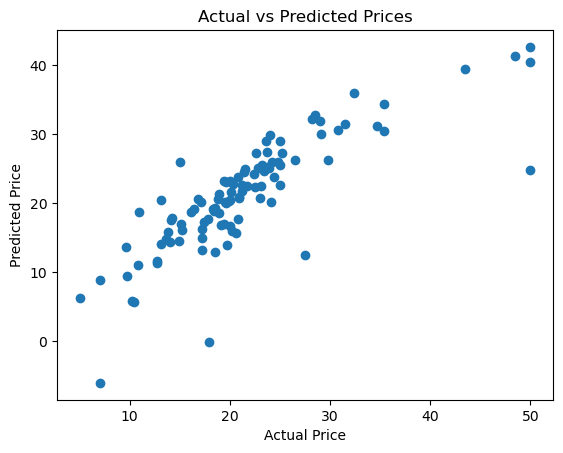

In [17]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

# 11. Residual Analysis

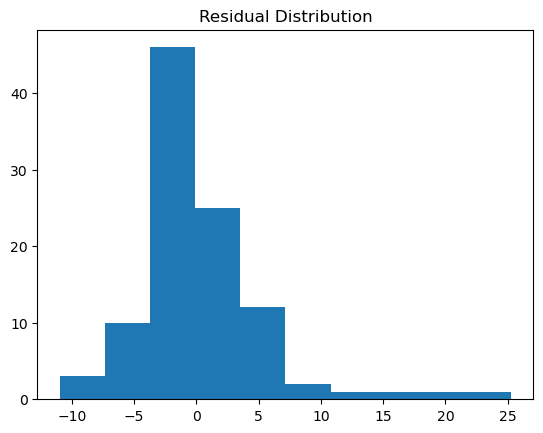

In [18]:
residuals = y_test - y_pred

plt.hist(residuals)
plt.title("Residual Distribution")
plt.show()

# 12. Feature Importance (Coefficients)

In [19]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coefficients.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
5,RM,4.438835
3,CHAS,2.784438
8,RAD,0.262430
2,INDUS,0.040381
1,ZN,0.030110
11,B,0.012351
6,AGE,-0.006296
9,TAX,-0.010647
0,CRIM,-0.113056
12,LSTAT,-0.508571


# Final Insights 

## Key Insights

- Model predicts house prices based on multiple features
- R² score shows how well model fits the data
- Features with higher coefficients have stronger impact on price
- Residuals should be normally distributed for good model performance

## Conclusion

- Linear Regression provides a baseline model
- Can be improved using advanced models like Random Forest or XGBoost